# Fallen angels: when a bond gets kicked out of the club, buy it 😇
### The forced-seller premium in high-yield bonds — tested live, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)
![Just duration + beta?: Busted](https://img.shields.io/badge/Just_duration_%2B_beta%3F-Busted-8b949e?style=flat-square)

A *fallen angel* is a bond that was born respectable — **investment-grade** — and then got downgraded to junk. Here's the strange part: a huge chunk of the bond market is **not allowed** to hold junk. Insurance companies, pension funds and investment-grade index funds *must* sell the moment the rating drops — whatever the price. The claim: that wave of **forced selling** pushes the price below fair value, and whoever buys the dumped bonds earns extra return as they recover.

For once, we don't need to reconstruct history from dusty index tables: since 2012 there has been a real, fee-charging ETF that holds **only fallen angels** (ANGL) and a real benchmark that holds ordinary junk bonds (HYG). The market has been running this experiment for **14 years, live, with real money**. We just read the tape.

> 📓 **Plain-language layer.** Want the regressions and the robustness checks? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it, from **total-return, net-of-fee** ETF prices. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fallen_angels_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_prices()                       # sliced to the frozen as-of 2026-06-30
    M = st.monthly_returns(PX)
    MC = st.align_common(M, ["ANGL", "HYG", "JNK", "IEF", "LQD", "BIL"])   # ANGL era
else:
    PX = M = MC = None
print("real ETF cache present:", HAVE_REAL,
      "| ANGL-era months:", (0 if MC is None else len(MC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '2009967185e2', 'start': '2012-05', 'end': '2026-06', 'n_months': 170, 'years': 14.2, 'spread_bps': 18.3, 'spread_t': 2.44, 'spread_pp': 2.18, 'ann': {'ANGL': 6.78, 'HYG': 4.6, 'JNK': 4.51}, 'sharpe': {'ANGL': 0.63, 'HYG': 0.46, 'JNK': 0.43}, 'specs': [('ANGL ~ HYG', 15.03, 2.36, 1.122, None), ('ANGL ~ HYG + IEF', 15.1, 2.38, 1.119, 0.011), ('ANGL ~ HYG + IEF + LQD', 15.83, 2.65, 0.749, -0.445), ('ANGL ~ JNK', 16.7, 2.86, 1.078, None), ('ANGL ~ JNK + IEF', 16.87, 2.92, 1.071, 0.033)], 't_ief': 0.2, 'faln': {'n': 120, 'start': '2016-07', 'spread': 14.16, 'spread_t': 1.64, 'alpha': 9.46, 'alpha_t': 1.43, 'dur_alpha': 7.64, 'dur_t': 1.22}, 'halves': [('2012-05 - 2019-06', 24.77, 2.28, 86), ('2019-07 - 2026-06', 11.68, 1.13, 84)], 'decay_diff': 13.09, 'decay_t': 0.83, 'dd': {'ANGL': -29.3, 'HYG': -22.0}, 'dd_dates': {'ANGL': '2020-02-14 - 2020-03-19', 'HYG': '2020-02-13 - 2020-03-23'}, 'costs': [(2.0, 0.3, 219), (5.0, 0.7, 219), (10.0, 1.4, 218)], 'syn': [(0.0, 5.87, 1.24, 2.61, 0.67), (20.0, 25.87, 5.47, 22.61, 5.78)]}


real ETF cache present: True | ANGL-era months: 170


## The answer first

| Question | Answer |
|---|---|
| Do the kicked-out bonds beat ordinary junk bonds? | **Yes — really.** The fallen-angel ETF has beaten the broad junk ETF by about **+2.2% per year for 14 years**, and the gap is statistically solid, not luck. |
| Is it just a riskier portfolio in disguise? | **Mostly no.** It does carry a bit more market sensitivity, but the extra return survives every "maybe it's just more duration / more risk" control we throw at it. |
| Can you actually collect it? | **Yes.** The whole thing is packaged in one liquid ETF. You buy ANGL instead of HYG — one trade, costs measured in *fractions* of a basis point per year. |
| What's the catch? | **The crash.** In March 2020 the fallen-angel fund fell **-29%** while ordinary junk fell **-22%**. You are paid for wearing the deeper drawdown, and the premium arrives in bursts after downgrade waves — not smoothly. |

## 1 · The claim

> *"When a company's bonds get downgraded from investment-grade to junk, armies of rule-bound investors are **forced to sell at any price**. The bonds land in the junk market oversold — and then outperform as they recover (some even get re-upgraded: 'rising stars')."*

This is not folklore — it's one of the best-documented effects in bond-market research (Ben Dor & Xu 2011; Ellul, Jotikasthira & Lundblad 2011 showed insurance companies literally *fire-sale* downgraded bonds because capital rules make them). Index studies going back to 1997 all show fallen angels beating ordinary junk. But index studies pay no fees and trade at fantasy prices — so our desk grades **only the live tape**: the actual ETF against the actual benchmark, both net of their real fees.

## 2 · So what?

If this premium is real *and* collectible, it's one of the rare cases where a retail investor can pick up an institutional inefficiency with **one trade**: the forced sellers are structurally locked in (the rules that force them to dump aren't going away), and the recovery accrues to whoever warehouses the bonds. If it's *not* real — if it's just a riskier portfolio dressed up — then ANGL is marketing, and you're better off in the cheaper, broader fund. Billions of dollars sit on each side of that question.

## 3 · How would we even know?

Simple and brutal: take every complete month since the fallen-angel ETF listed (**2012-05 → 2026-06, 170 months**) and compare **ANGL** (only fallen angels) with **HYG** (ordinary junk), total-return and net of each fund's real fee. Then:

1. **Measure the gap** — the monthly return difference, with statistics that don't get fooled by streaky months.
2. **Try to kill it** — maybe ANGL just holds *longer-duration* or *more market-sensitive* bonds? We add those factors and see if the extra return dies.
3. **Price the pain** — compare the crashes, and the cost of actually doing the trade.

## 4 · The teardown — let's actually look

**Growth of $100** in the fallen-angel ETF vs the broad junk ETF, since the day both traded.

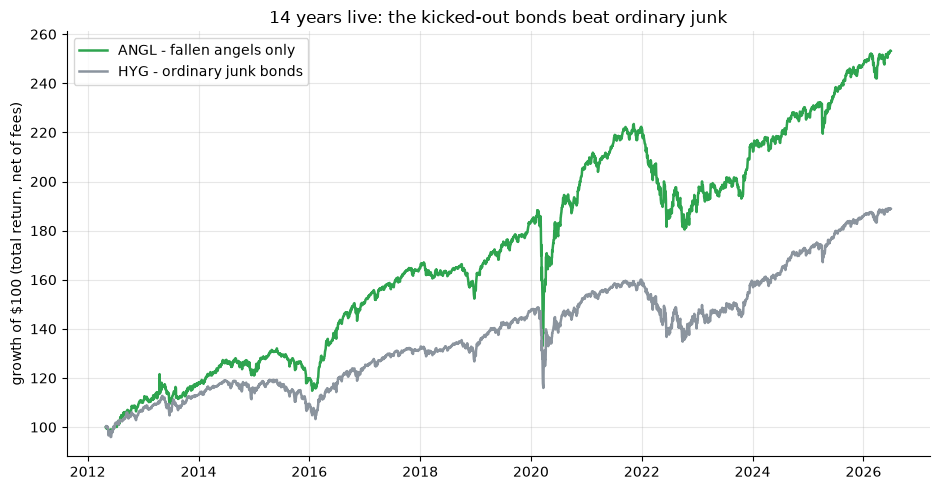

final: ANGL $253  vs  HYG $189


In [2]:
if HAVE_REAL:
    px = PX[["ANGL", "HYG"]].loc["2012-04-30":].dropna()
    g = 100.0 * px / px.iloc[0]
    fig, ax = plt.subplots()
    ax.plot(g.index, g["ANGL"], c=GREEN, lw=1.8, label="ANGL - fallen angels only")
    ax.plot(g.index, g["HYG"], c=GREY, lw=1.8, label="HYG - ordinary junk bonds")
    ax.set_ylabel("growth of $100 (total return, net of fees)")
    ax.set_title("14 years live: the kicked-out bonds beat ordinary junk")
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final: ANGL ${g["ANGL"].iloc[-1]:.0f}  vs  HYG ${g["HYG"].iloc[-1]:.0f}')
else:
    print('cache missing - frozen numbers:', R['ann'])

The fallen-angel fund compounds at **6.78%/yr** vs **4.60%/yr** for ordinary junk — a gap of **+2.2 percentage points every year**, after fees, for 14 years. The quants notebook confirms the gap is statistically real (HAC *t* = 2.44, above the desk's *t* ≥ 2 bar) — not one lucky stretch.

**Is it just a riskier portfolio in disguise?** The two classic outs: maybe fallen angels are just *longer-duration* bonds (they were born investment-grade, so they're longer), or just *more market-sensitive*. We regress the extra return on those factors — if the "premium" is a costume, it dies; if it's real, it survives.

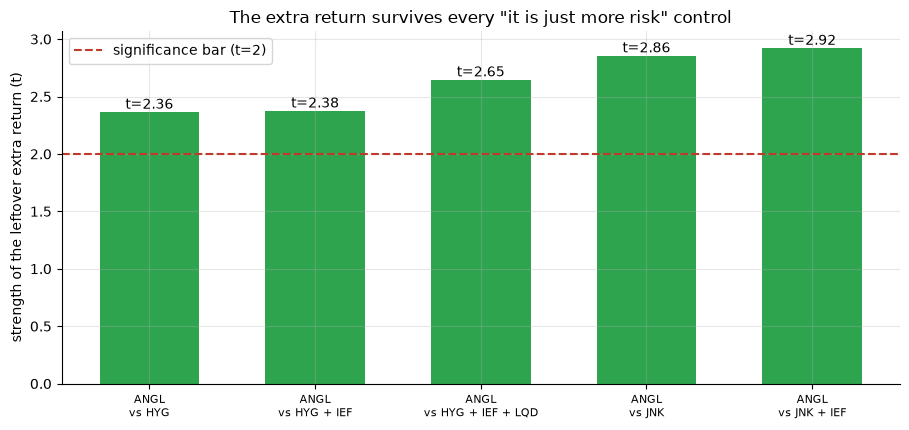

alpha t across specs: [np.float64(2.36), np.float64(2.38), np.float64(2.65), np.float64(2.86), np.float64(2.92)]


In [3]:
labels = [s[0] for s in R['specs']]
tvals  = [s[2] for s in R['specs']]
if HAVE_REAL:
    rr = [st.capm_alpha(MC, 'ANGL', 'HYG'),
          st.factor_alpha(MC, 'ANGL', ['HYG', 'IEF']),
          st.factor_alpha(MC, 'ANGL', ['HYG', 'IEF', 'LQD']),
          st.capm_alpha(MC, 'ANGL', 'JNK'),
          st.factor_alpha(MC, 'ANGL', ['JNK', 'IEF'])]
    tvals = [r['t_alpha'] for r in rr]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(range(len(tvals)), tvals, color=GREEN, width=.6)
ax.axhline(2, ls='--', c=RED, label='significance bar (t=2)')
for i, v in enumerate(tvals): ax.annotate(f't={v:.2f}', (i, v), ha='center', va='bottom')
ax.set_xticks(range(len(labels))); ax.set_xticklabels([l.replace(' ~ ', '\nvs ') for l in labels], fontsize=8)
ax.set_ylabel('strength of the leftover extra return (t)')
ax.set_title('The extra return survives every "it is just more risk" control')
ax.legend(); plt.tight_layout(); plt.show()
print('alpha t across specs:', [round(v, 2) for v in tvals])

Every bar clears the significance line. Adding the *duration* factor changes nothing (its loading is basically zero, *t* = 0.2); swapping the benchmark (JNK) makes it *stronger*. About 3 of the 18 monthly basis points **are** just extra market sensitivity — the honest deduction — but the remaining **~15 bps/month of genuine alpha** refuses to die. The forced-seller story fits; the costume story doesn't.

**The catch — the crash you carry.** Nothing in markets is free; here's the bill, in drawdown form, around COVID (the one big downgrade wave of the sample).

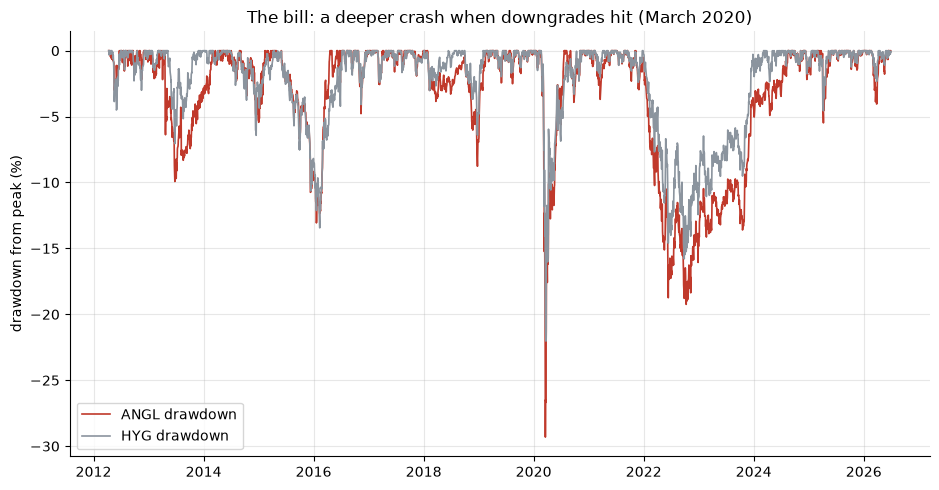

max DD: ANGL -29.3%  vs  HYG -22.0%


In [4]:
if HAVE_REAL:
    px = PX[["ANGL", "HYG"]].loc["2012-04-11":].dropna()
    dd = px / px.cummax() - 1.0
    fig, ax = plt.subplots()
    ax.plot(dd.index, dd["ANGL"]*100, c=RED, lw=1.2, label="ANGL drawdown")
    ax.plot(dd.index, dd["HYG"]*100, c=GREY, lw=1.2, label="HYG drawdown")
    ax.set_ylabel("drawdown from peak (%)")
    ax.set_title("The bill: a deeper crash when downgrades hit (March 2020)")
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'max DD: ANGL {dd["ANGL"].min()*100:.1f}%  vs  HYG {dd["HYG"].min()*100:.1f}%')
else:
    print('cache missing - frozen numbers:', R['dd'])

In March 2020 the fallen-angel fund dropped **-29.3%** peak-to-trough vs **-22.0%** for ordinary junk — about **7 points deeper**. That's the price of admission: when a downgrade wave hits, you're the one catching the falling bonds. The premium is your pay for that job.

## 5 · The verdict

- **Signal — Real.** +2.2%/yr over ordinary junk for 14 live years, statistically solid, and it survives the duration and risk-costume controls.
- **Tradability — Investable.** One liquid ETF, one switch, cost drag near zero, fees already inside the numbers. Rare on this desk.
- **"Just duration + more risk"? — Busted.** The duration factor loads at zero; the beta deduction takes ~3 bps of 18; the ~15 bps/month leftover is genuine alpha.

The honest caveats, out loud: the newer copycat fund (FALN, 2016→) points the same way but its shorter window can't certify alone; the last seven years alone are positive but noisier (the premium arrives in bursts after downgrade waves); and you wear a deeper crash when the wave hits.

## 6 · Going further 🚪

- **Why doesn't it get arbitraged away?** The sellers aren't stupid — they're *constrained*. Capital rules and index mandates force the dump; as long as those rules exist, someone gets paid to warehouse the bonds. Structural, not informational.
- **Why is the premium bursty?** It needs raw material: downgrade waves (2016 energy, 2020 COVID). Quiet years mint few fallen angels, so the edge idles.
- **Related desks:** [Study 115 — Credit-Spreads](../../115-credit-spreads/) (do HY spreads predict *equities*?) and [Study 340 — Bank-Loans](../../340-bank-loans/) (is floating-rate credit a *safe bond substitute*?) test the other legs of the credit folklore.

*Think the premium dies as ETFs crowd the trade? The 2019→2026 half is the place to look — bring a longer tape and we'll re-grade.*